In [1]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path
from datetime import datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

project_root = Path.cwd()
while project_root.name != 'python' and project_root.parent != project_root:
    project_root = project_root.parent

if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

## Downloading the data

In [2]:
from data import download_tickers_history
from data.constants import TRADING_DAYS_PER_YEAR

# set the date range for the historic data
start_date = datetime(year=2022, month=1, day=1)
end_date = datetime(year=2026, month=1, day=1)
tickers = ['NVDA', 'AAPL', 'PLTR', 'DKNG', 'CAT', 'INTC', 'AMZN', 'TSLA', 'GOOG', 'MSFT']
history = download_tickers_history(start_date, end_date, tickers)

history.head()


Ticker           DKNG                                                   AMZN  \
Price            Open       High        Low      Close    Volume        Open   
Date                                                                           
2022-01-03  27.844999  28.549999  26.969999  27.770000  11252200  167.550003   
2022-01-04  27.750000  27.870001  26.110001  26.629999  15306200  170.438004   
2022-01-05  26.500000  26.910000  24.059999  24.650000  22277000  166.882996   
2022-01-06  24.500000  26.469999  23.209999  25.799999  30469400  163.450500   
2022-01-07  26.020000  27.980000  25.790001  27.240000  26266200  163.839005   

Ticker                                                    ...       INTC  \
Price             High         Low       Close    Volume  ...       Open   
Date                                                      ...              
2022-01-03  170.703506  166.160507  170.404495  63520000  ...  47.903634   
2022-01-04  171.399994  166.349503  167.522003  70726000  ...  49.684371   
2022-01-05  167.126495  164.356995  164.356995  64302000  ...  50.259401   
2022-01-06  164.800003  161.936996  163.253998  51958000  ...  50.648939   
2022-01-07  165.243500  162.031006  162.554001  46606000  ...  50.259404   

Ticker                                                        CAT              \
Price            High        Low      Close    Volume        Open        High   
Date                                                                            
2022-01-03  49.369029  47.857258  49.350479  33857600  191.295615  192.467400   
2022-01-04  50.027533  48.831104  49.285561  45681400  192.172153  201.989282   
2022-01-05  52.095784  49.925516  49.962612  59109300  201.306540  206.085940   
2022-01-06  50.704584  49.545252  50.092457  35757900  204.360553  205.486202   
2022-01-07  50.444898  49.294842  49.563805  30717200  205.292443  208.494084   

Ticker                                       
Price              Low       Close   Volume  
Date                                         
2022-01-03  189.883942  190.991135  2055600  
2022-01-04  191.858451  201.214249  5242300  
2022-01-05  201.306540  202.755127  5378200  
2022-01-06  201.195813  204.821884  3913200  
2022-01-07  205.043321  206.851746  3673400  

[5 rows x 50 columns]

In [21]:
from data.processors import log_returns

log_ret = log_returns(history)
yr_cov = np.array(log_ret.cov() * TRADING_DAYS_PER_YEAR)  # type: ignore
num_assets = yr_cov.shape[0]
weights = np.ones(num_assets) / num_assets;
expected_returns = np.array(log_ret.mean() * TRADING_DAYS_PER_YEAR)

Manual calculation

In [14]:
from src.portfolio import black_litterman, get_risk_free_rate

risk_free_rate = get_risk_free_rate('T_BILLS', start_date, end_date, 'BACKTEST')

# 'AAPL' will be greater than 'MSFT' by 4% annually
Q = np.array([[.04]]) # vector of views values
assets = history.columns.get_level_values(0).unique()
P = np.array([[1 if t == 'AAPL' else -1 if t == 'MSFT' else 0 for t in assets]])
black_litterman_vector = black_litterman(expected_returns, yr_cov, risk_free_rate, Q, P)
black_litterman_vector


array([0.20007122, 0.21890051, 0.12213405, 0.09890493, 0.0988093 ,
       0.1887942 , 0.17664937, 0.12620907, 0.07820158, 0.06799343])

## Data visualization

Find the Sharpe ratio

In [14]:
from src.portfolio import get_risk_free_rate, find_max_sharpe

risk_free_rate = get_risk_free_rate('T_BILLS', start_date, end_date)

# Investor's views
# 'AAPL' will be greater than 'MSFT' by 4% annually
Q = np.array([[.04]]) # vector of views values
assets = history.columns.get_level_values(0).unique()
P = np.array([[1 if t == 'AAPL' else -1 if t == 'MSFT' else 0 for t in assets]])

(max_sharpe, stocks_w) = find_max_sharpe(
    tickers_df=history,
    rf_base='T_BILLS',
    opt_models=['LEDOIT_WOLF', 'BLACK_LITTERMAN'],
    views=Q,
    views_transition=P)

exact_max_ret = max_sharpe.tangency_return
exact_max_vol = max_sharpe.tangency_vol
exact_max_sharpe = max_sharpe.max_sharpe

print(f"Exact Max Sharpe Ratio: {max_sharpe.max_sharpe:.4f}")
print(f"Exact Tangency Return: {exact_max_ret:.2%}")
print(f"Exact Tangency Volatility: {exact_max_vol:.2%}")

print("Exact optimum stocks distribution:")
stocks_w


Exact Max Sharpe Ratio: 0.3272
Exact Tangency Return: 18.26%
Exact Tangency Volatility: 42.99%
Exact optimum stocks distribution:


,DKNG,AMZN,PLTR,TSLA,NVDA,GOOG,MSFT,AAPL,INTC,CAT
0,17.0,2.0,21.0,23.0,22.0,0.0,0.0,5.0,11.0,0.0


Sharpe with no investor's hypothesis

In [17]:
from src.portfolio import get_risk_free_rate, find_max_sharpe

risk_free_rate = get_risk_free_rate('T_BILLS', start_date, end_date)

(max_no_views_sharpe, no_views_stocks_w) = find_max_sharpe(
    tickers_df=history,
    rf_base='T_BILLS',
    opt_models=['LEDOIT_WOLF', 'BLACK_LITTERMAN'])

exact_no_views_max_ret = max_no_views_sharpe.tangency_return
exact_no_views_max_vol = max_no_views_sharpe.tangency_vol
exact_no_views_max_sharpe = max_no_views_sharpe.max_sharpe

print(f"Exact Max Sharpe Ratio: {exact_no_views_max_sharpe:.4f}")
print(f"Exact Tangency Return: {exact_no_views_max_ret:.2%}")
print(f"Exact Tangency Volatility: {exact_no_views_max_vol:.2%}")

print("Exact optimum stocks distribution:")
no_views_stocks_w


Exact Max Sharpe Ratio: 0.3268
Exact Tangency Return: 18.38%
Exact Tangency Volatility: 43.40%
Exact optimum stocks distribution:


,DKNG,AMZN,PLTR,TSLA,NVDA,GOOG,MSFT,AAPL,INTC,CAT
0,17.0,6.0,21.0,20.0,25.0,0.0,0.0,0.0,10.0,0.0


Find Sortino ratio

In [ ]:
from src.portfolio import get_risk_free_rate, find_max_sortino

risk_free_rate = get_risk_free_rate('T_BILLS', start_date, end_date)

# Investor's views
# 'AAPL' will be greater than 'MSFT' by 4% annually
Q = np.array([[.04]]) # vector of views values
assets = history.columns.get_level_values(0).unique()
P = np.array([[1 if t == 'AAPL' else -1 if t == 'MSFT' else 0 for t in assets]])

(max_sortino, stocks_w) = find_max_sortino(
    tickers_df=history,
    rf_base='T_BILLS',
    opt_models=['LEDOIT_WOLF', 'BLACK_LITTERMAN'],
    views=Q,
    views_transition=P)

max_sortino_ret = max_sortino.tangency_return
max_sortino_vol = max_sortino.tangency_vol
max_sortino_sortino = max_sortino.max_sortino

print(f"Exact Max Sortino Ratio: {max_sortino.max_sortino:.4f}")
print(f"Exact Sortino Return: {max_sortino_ret:.2%}")
print(f"Exact Sortino Volatility: {max_sortino_vol:.2%}")

print("Exact optimum stocks distribution:")
stocks_w


Exact Max Sortino Ratio: 0.4609
Exact Sortino Return: 18.34%
Exact Sortino Volatility: 30.71%
Exact optimum stocks distribution:


,DKNG,AMZN,PLTR,TSLA,NVDA,GOOG,MSFT,AAPL,INTC,CAT
0,12.0,0.0,28.0,20.0,22.0,0.0,0.0,9.0,8.0,0.0


Sortino with no investor's hypothesis

In [16]:
(max_no_views_sortino, no_views_stocks_w) = find_max_sortino(
    tickers_df=history,
    rf_base='T_BILLS',
    opt_models=['LEDOIT_WOLF', 'BLACK_LITTERMAN'])

max_no_views_sortino_ret = max_no_views_sortino.tangency_return
max_no_views_sortino_vol = max_no_views_sortino.tangency_vol
max_no_views_sortino_sortino = max_no_views_sortino.max_sortino

print(f"Exact Max Sortino Ratio: {max_no_views_sortino.max_sortino:.4f}")
print(f"Exact Sortino Return: {max_no_views_sortino_ret:.2%}")
print(f"Exact Sortino Volatility: {max_no_views_sortino_vol:.2%}")

print("Exact optimum stocks distribution:")
no_views_stocks_w

Exact Max Sortino Ratio: 0.4607
Exact Sortino Return: 19.17%
Exact Sortino Volatility: 32.52%
Exact optimum stocks distribution:


,DKNG,AMZN,PLTR,TSLA,NVDA,GOOG,MSFT,AAPL,INTC,CAT
0,14.0,0.0,30.0,19.0,30.0,0.0,0.0,0.0,8.0,0.0


Equal weights return

In [24]:
eq_weights_ret = weights @ expected_returns
eq_weights_vol = float(np.sqrt(weights.T @ yr_cov @ weights))

print(f"Equal weights return: {eq_weights_ret:.2%}")
print(f"Sortino return - Equal weights return: {(max_sortino_ret - eq_weights_ret):.2%}")
print(f"Sortino risk - Equal weights risk: {(max_sortino_vol - eq_weights_vol):.2%}")


Equal weights return: 17.92%
Sortino return - Equal weights return: 0.42%
Sortino risk - Equal weights risk: -0.90%


Optimize portfolio for the Efficient Frontier visualization

In [19]:
from src.portfolio import optimize_portfolio

optimum_df = optimize_portfolio(
    tickers_df=history,
    rf_base='T_BILLS',
    opt_models=['LEDOIT_WOLF', 'BLACK_LITTERMAN'],
    views=Q,
    views_transition=P)
optimum_df


,weights,return,vol,sharpe,sortino
0,"[0.0, 0.0, 3.469446951953614e-18, 1.0299920638...",0.081183,0.222609,0.176458,0.252826
1,"[4.2825985813177425e-18, 0.0, 5.42101086242752...",0.082573,0.222820,0.182527,0.261214
2,"[0.0008488849972557752, 1.1438332919722072e-17...",0.083962,0.223382,0.188289,0.269198
3,"[0.012140215770781592, 0.0, 0.0, 0.0, 8.131516...",0.085352,0.224202,0.193798,0.276795
4,"[0.017127368902235613, 8.782037597132586e-18, ...",0.086741,0.225161,0.199143,0.284159
...,...,...,...,...,...
85,"[0.18116718120991174, 1.778809265089626e-17, 0...",0.199295,0.487416,0.322913,0.457097
86,"[0.17485991763695943, 6.195424956690449e-17, 0...",0.200685,0.494000,0.321422,0.456079
87,"[0.1683789907482069, 4.530029554253289e-17, 0....",0.202074,0.501265,0.319536,0.454586
88,"[0.1703603400531903, 0.0, 0.3999999999999999, ...",0.203464,0.509532,0.317078,0.451164


Visualize the data

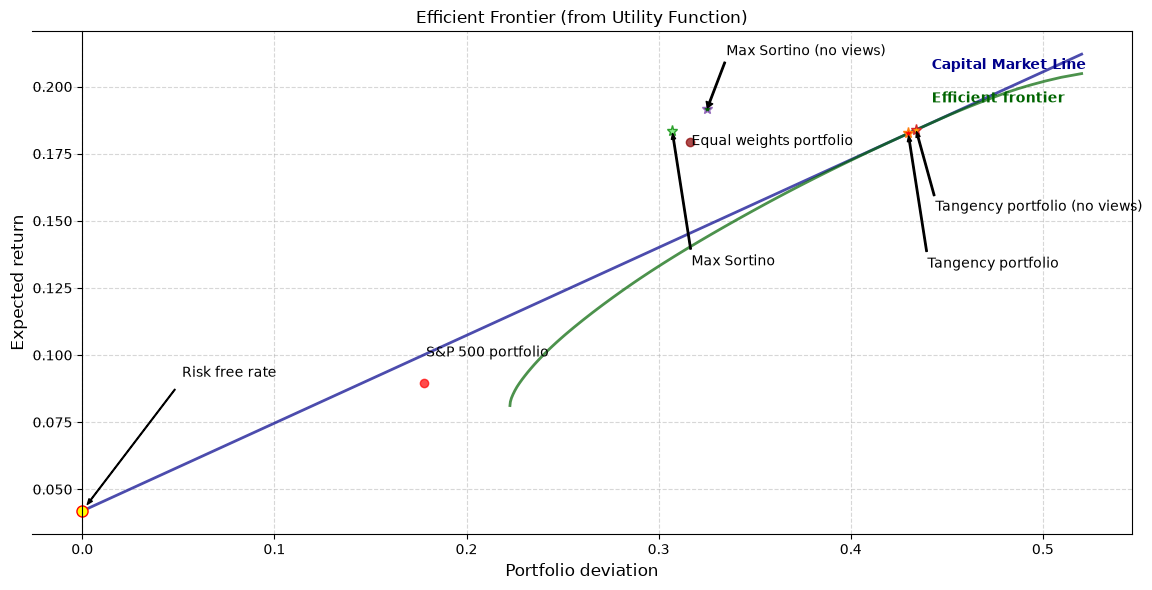

In [37]:
from data.processors import log_returns

fig, ax = plt.subplots(figsize=(12, 6))

vol = optimum_df['vol']
sharpe = optimum_df['sharpe']
returns = optimum_df['return']
max_vol = vol.max()
max_sharpe = sharpe.max()
max_sharpe_ind = sharpe.idxmax()
log_ret = log_returns(history)
expected_returns = log_ret.mean() * TRADING_DAYS_PER_YEAR

# capital distribution line
cal_x = np.linspace(0, max_vol, 100)
cal_y = max_sharpe * cal_x + risk_free_rate

ax.plot(
    cal_x,
    cal_y,
    color='darkblue',
    alpha=0.7,
    linewidth=2, 
)
ax.spines['left'].set_position('zero')
x_label = max_vol * 0.85
y_label = max_sharpe * x_label + risk_free_rate

# Add text on the plot
ax.text(
    x_label,
    y_label + 0.02,
    'Capital Market Line',
    color='darkblue',
    fontweight='bold'
)

# mark risk free rate point
plt.plot(0, risk_free_rate, marker="o", markersize=8, markeredgecolor="red", markerfacecolor="yellow")
plt.annotate(
    'Risk free rate',
    xy=(0, risk_free_rate),
    xytext=(risk_free_rate + 0.01, risk_free_rate + 0.05),
    arrowprops=dict(facecolor='black', width=0.5, headwidth=3, headlength=4, shrink=0.05)
)

# effective frontier
ef_x = vol
ef_y = returns
ax.plot(
    ef_x,
    ef_y,
    color='darkgreen',
    alpha=0.7,
    linewidth=2,
)

# equal weights portfolio
x0 = np.ones(num_assets) / num_assets
def_x = float(np.sqrt(x0.T @ yr_cov @ x0))
def_y = np.dot(x0, expected_returns)
ax.scatter(
    def_x,
    def_y,
    color='darkred',
    alpha=0.7,
)
plt.text(def_x + 0.001, def_y - 0.001, 'Equal weights portfolio')

# S&P 500 portfolio
sp500_df = download_tickers_history(start_date, end_date, ['^GSPC'])
sp500_log_ret = log_returns(sp500_df)

sp500_x = sp500_log_ret.std().iloc[0] * np.sqrt(TRADING_DAYS_PER_YEAR)
sp500_y = sp500_log_ret.mean().iloc[0] * TRADING_DAYS_PER_YEAR
ax.scatter(
    sp500_x,
    sp500_y,
    color='red',
    alpha=0.7,
)
plt.text(sp500_x + 0.001, sp500_y + 0.01, 'S&P 500 portfolio')

x_label = max_vol * 0.85
y_label = returns.max() * 0.85
# Add text on the plot
ax.text(
    x_label,
    y_label + 0.02,
    'Efficient frontier',
    color='darkgreen',
    fontweight='bold'
)

# mark the tangency portfolio point
plt.plot(exact_max_vol, exact_max_ret, marker="*", markersize=8, markerfacecolor="red")
plt.annotate(
    'Tangency portfolio',
    xy=(exact_max_vol, exact_max_ret),
    xytext=(exact_max_vol + 0.01, exact_max_ret - 0.05),
    arrowprops=dict(facecolor='black', width=1, headwidth=3, headlength=4, shrink=0.02)
)

# mark the max Sortino point
plt.plot(max_sortino_vol, max_sortino_ret, marker="*", markersize=8, markerfacecolor="lightgreen")
plt.annotate(
    'Max Sortino',
    xy=(max_sortino_vol, max_sortino_ret),
    xytext=(max_sortino_vol + 0.01, max_sortino_ret - 0.05),
    arrowprops=dict(facecolor='black', width=1, headwidth=3, headlength=4, shrink=0.02)
)

# mark the tangency portfolio point with no trader's views
plt.plot(exact_no_views_max_vol, exact_no_views_max_ret, marker="*", markersize=8, markerfacecolor="orange")
plt.annotate(
    'Tangency portfolio (no views)',
    xy=(exact_no_views_max_vol, exact_no_views_max_ret),
    xytext=(exact_no_views_max_vol + 0.01, exact_no_views_max_ret - 0.03),
    arrowprops=dict(facecolor='black', width=1, headwidth=3, headlength=4, shrink=0.02)
)

# mark the max Sortino point with no trader's views
plt.plot(max_no_views_sortino_vol, max_no_views_sortino_ret, marker="*", markersize=8, markerfacecolor="darkgreen")
plt.annotate(
    'Max Sortino (no views)',
    xy=(max_no_views_sortino_vol, max_no_views_sortino_ret),
    xytext=(max_no_views_sortino_vol + 0.01, max_no_views_sortino_ret + 0.02),
    arrowprops=dict(facecolor='black', width=1, headwidth=5, headlength=4, shrink=0.02)
)

plt.title('Efficient Frontier (from Utility Function)')
plt.xlabel('Portfolio deviation', fontsize=12)
plt.ylabel('Expected return', fontsize=12)

plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

plt.show()
